In [1]:
import pandas as pd
import numpy as np
import sklearn as sl
import os
import sys
import scipy as sc
import statsmodels as st


In [2]:
import matplotlib.pyplot as plt
import utils as ut
import files as fl

<Axes: >

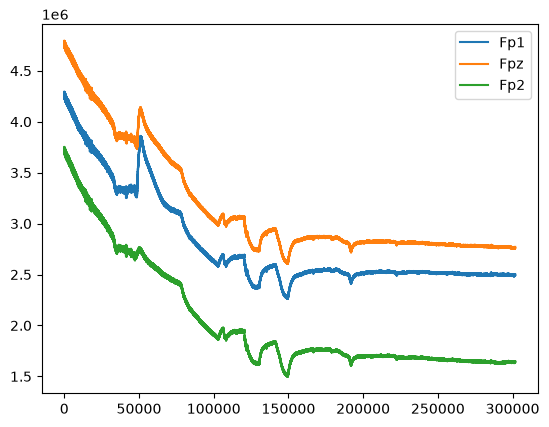

In [3]:
graphs = []
for i in [1]:
    file=f"data/0201000{i}_still.txt"
    # print(file)
    data = pd.read_csv(file, sep=" ")
    data.columns=['Fp1', 'Fpz', 'Fp2']
    graphs.append(data)

# for i in range(1):
graphs[0].plot()


In [4]:
from scipy.signal import butter,filtfilt
def pass_filter(data, cutoff, sampling_frequency, filter_type, filter_order, analog=False):
    nyquist_frequency = 0.5 * sampling_frequency
    normal_cutoff = cutoff / nyquist_frequency
    b, a = butter(filter_order, normal_cutoff, btype=filter_type, analog=analog)
    print([b,a])
    filtered = filtfilt(b, a, data)
    # print(data)
    # print(y)
    return filtered

order = 4

def high_pass_filter(data, cutoff:float,sampling_frequency:int):
    return pass_filter(data, cutoff , sampling_frequency, 'high', order)
    
def low_pass_filter(data, cutoff:float,sampling_frequency:int):
    return pass_filter(data, cutoff , sampling_frequency, 'low', order)

def band_pass_filter(data, band=np.asarray([1.0, 40.0]),sampling_frequency:int=250):
    nyq = 0.5 * sampling_frequency
    b, a = butter(4, [band[0]/nyq, band[1]/nyq], btype="band")
    y = filtfilt(b, a, data, axis=-1)
    return y

[array([ 0.57919222, -0.57919222]), array([ 1.        , -0.15838444])]
[array([ 0.57919222, -0.57919222]), array([ 1.        , -0.15838444])]


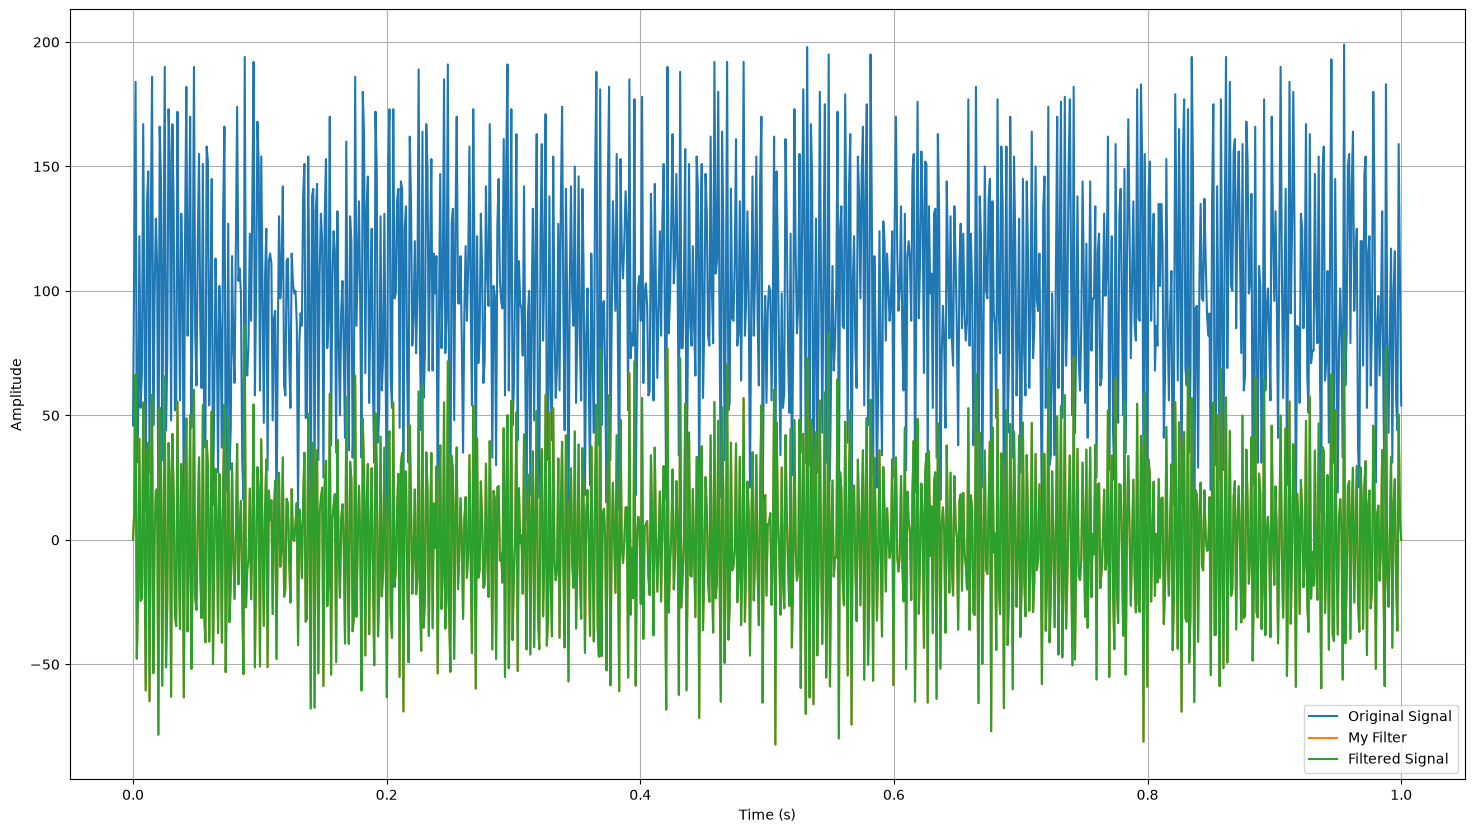

In [5]:
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Filter parameters
cutoff_freq = 200  # Cutoff frequency in Hz
fs = 1000  # Sampling rate in Hz
order = 1  # Filter order
# Design the high-pass filter (change btype to 'highpass')
nyq = 0.5 * fs
normal_cutoff = cutoff_freq / nyq
b, a = butter(order, normal_cutoff, btype='highpass')  # <-- modify here
print([b,a])
# Sample data (with time vector)
t = np.linspace(0, 1, 1000)  # Time vector for 1 second signal
data = 100*np.sin(2*np.pi*150*t)*np.sin(2*np.pi*150*t) + np.random.rand(1000)*100  # Example signal with noise
data = data.astype(int)
# Apply the filter
filtered_data = filtfilt(b, a, data)
my_filter = high_pass_filter(data,200,1000)

# Plot the original and filtered data
plt.figure(figsize=(18, 10))
plt.plot(t, data, label='Original Signal')
plt.plot(t, my_filter, label='My Filter')
plt.plot(t, filtered_data, label='Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

<Axes: >

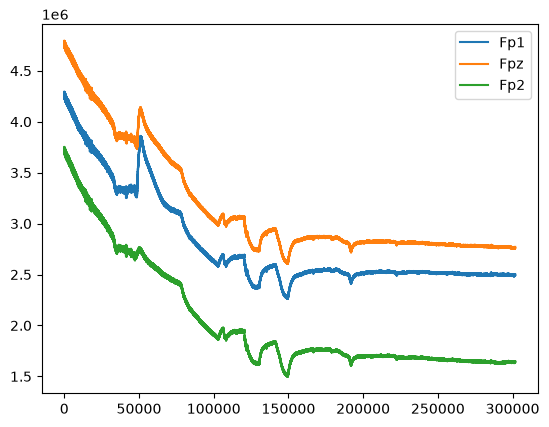

In [6]:
arquivo = "data/02010001_still.txt"
data = pd.read_csv(arquivo, sep=" ")
data.columns=['Fp1', 'Fpz', 'Fp2']
data.plot()

[array([0.35473657, 0.35473657]), array([ 1.        , -0.29052686])]
[array([ 0.98758894, -0.98758894]), array([ 1.        , -0.97517788])]
[array([0.35473657, 0.35473657]), array([ 1.        , -0.29052686])]
[array([ 0.98758894, -0.98758894]), array([ 1.        , -0.97517788])]
[array([0.35473657, 0.35473657]), array([ 1.        , -0.29052686])]
[array([ 0.98758894, -0.98758894]), array([ 1.        , -0.97517788])]


<Axes: >

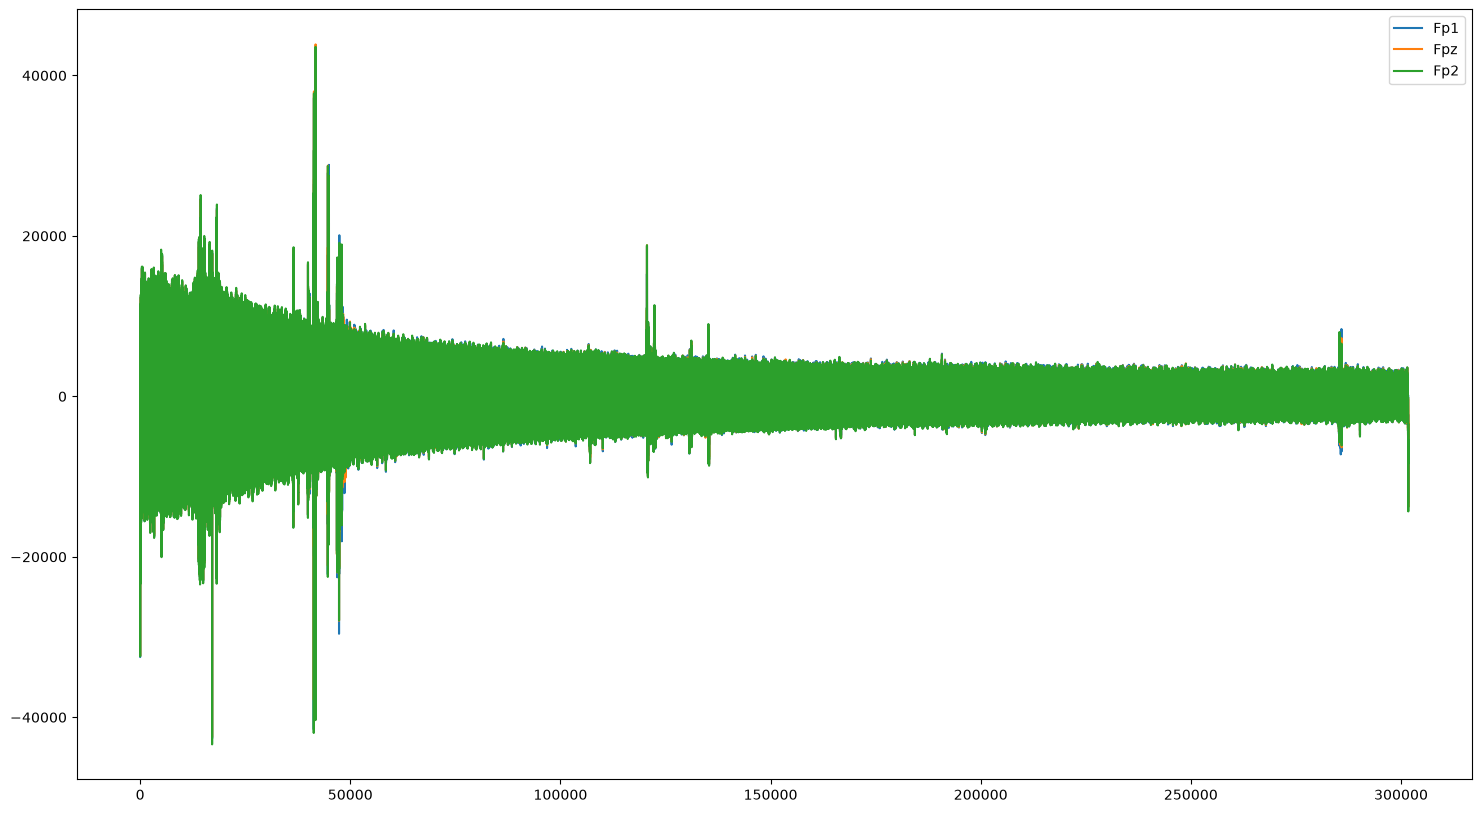

In [7]:
data = pd.read_csv(arquivo, sep=" ")
data.columns=['Fp1', 'Fpz', 'Fp2']
# print(data.columns)
for column in data.columns:
    a=2
    data[column]=low_pass_filter(data[column],40.0,250)
    data[column]=high_pass_filter(data[column],1,250)

# print(data)
data.plot(figsize=(18,10))

[[1492506.6714191  1479692.6714191  1440876.6714191  ... -317285.3285809
  -310233.3285809  -303639.3285809 ]
 [1627029.48797309 1614493.48797309 1575998.48797309 ... -413514.51202691
  -406418.51202691 -399795.51202691]
 [1710013.64386558 1696604.64386558 1657357.64386558 ... -410903.35613442
  -403374.35613442 -396551.35613442]]
(3, 301740)


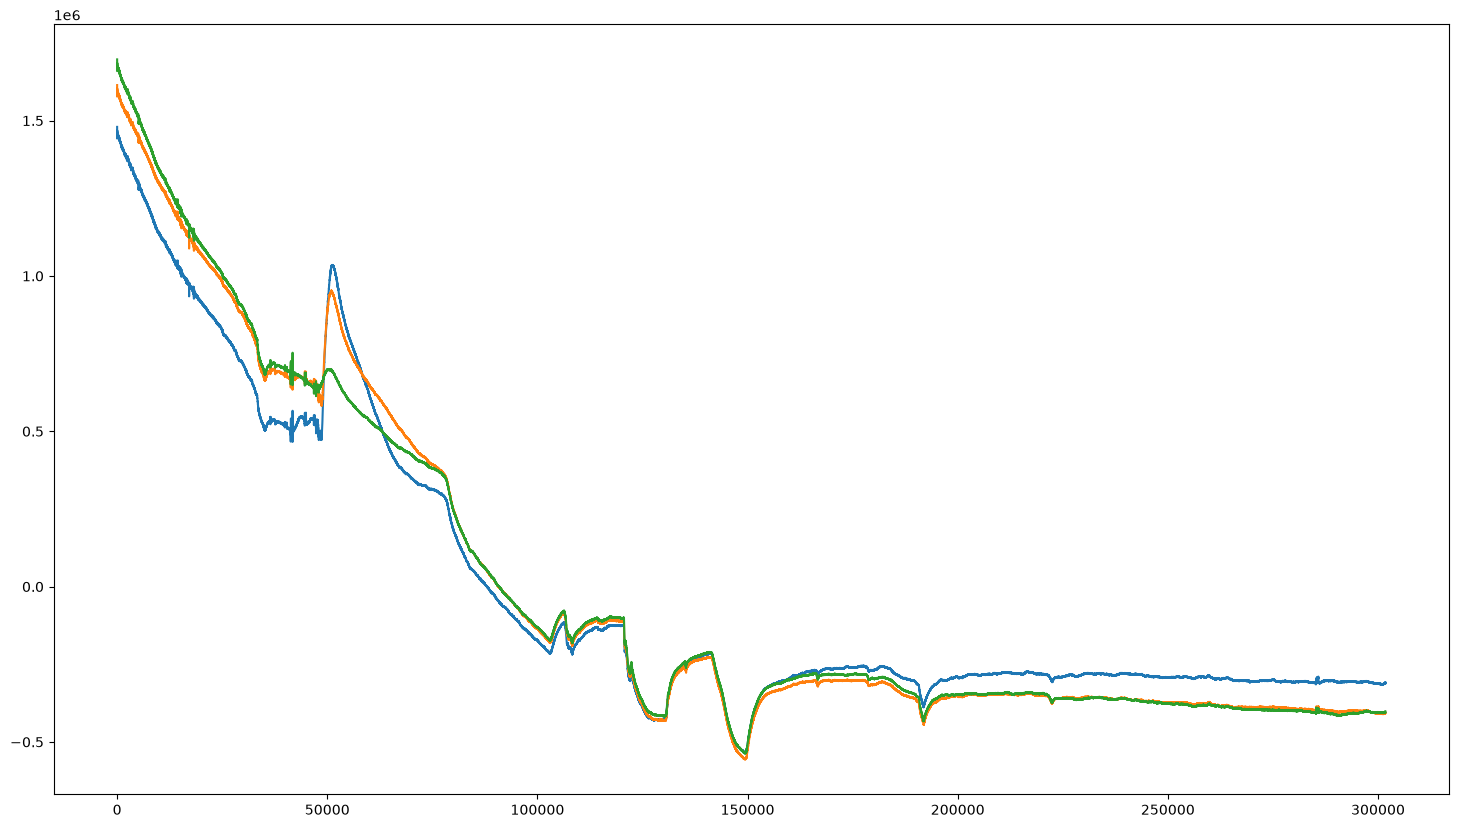

In [11]:
from scipy.signal import iirnotch, filtfilt
columns_labels = ['Fp1', 'Fpz', 'Fp2'];
data = pd.read_csv(arquivo, sep=" ", header=None, names=columns_labels)
# print(data.values.shape)
data_np =np.transpose(data.to_numpy().astype(float))
ymean = data_np - data_np.mean(axis=-1, keepdims=True)
print(ymean)


bn, an = iirnotch(50, Q=30, fs=250)
# print(bn)
# print(an)
print(ymean.shape)
filtered = filtfilt(bn, an, ymean, axis=-1)

plt.figure(figsize=(18,10))
plt.plot(filtered[0])
plt.plot(filtered[1])
plt.plot(filtered[2])
plt.show()


(3, 301740)
(3, 301740)


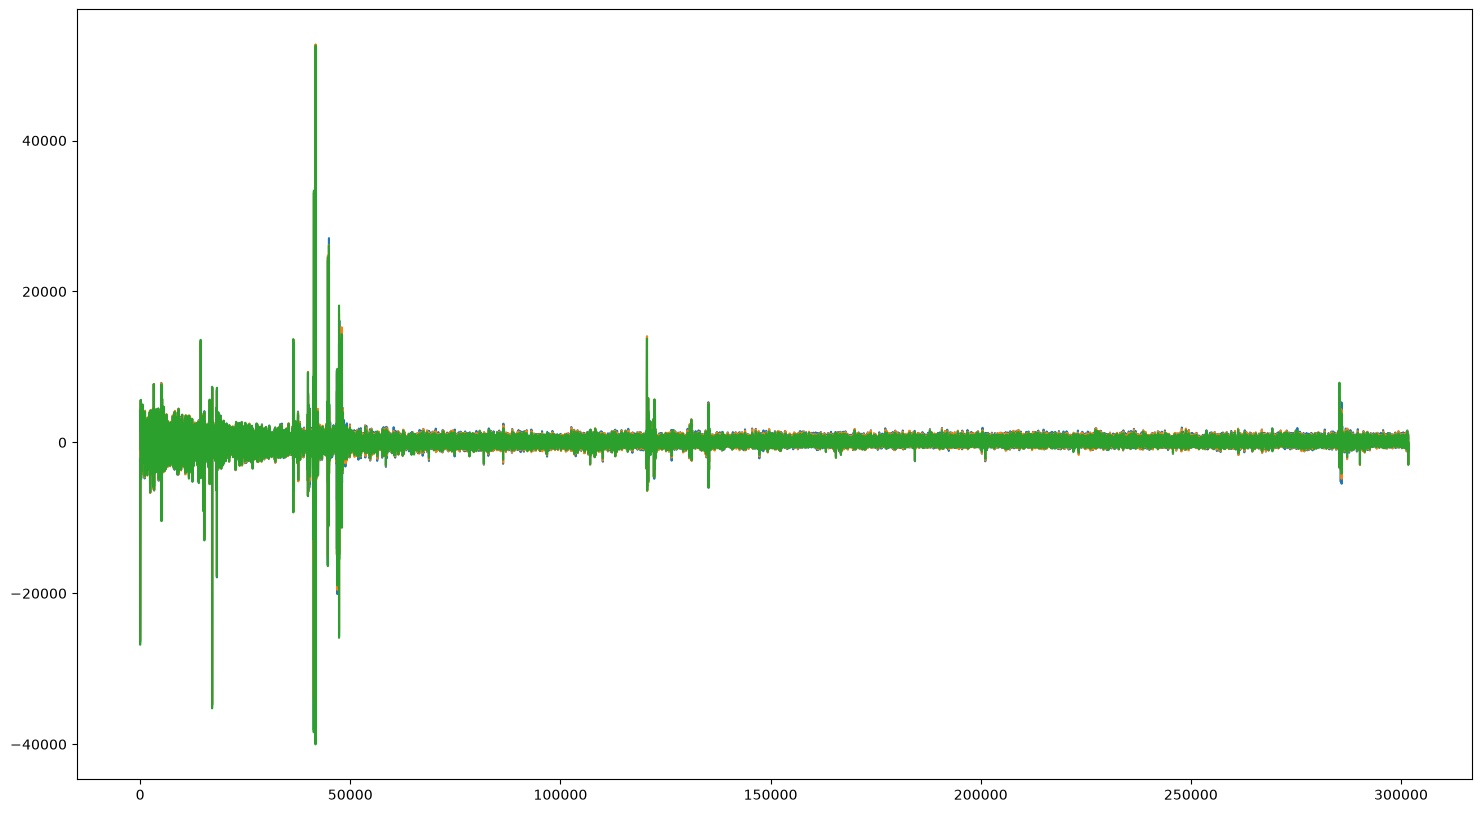

In [9]:
print(filtered.shape)
band_filtered = band_pass_filter(filtered)
print(band_filtered.shape)
plt.figure(figsize=(18,10))
plt.plot(band_filtered[0])
plt.plot(band_filtered[1])
plt.plot(band_filtered[2])
plt.show()

(3, 301740)
500
(3, 300740)


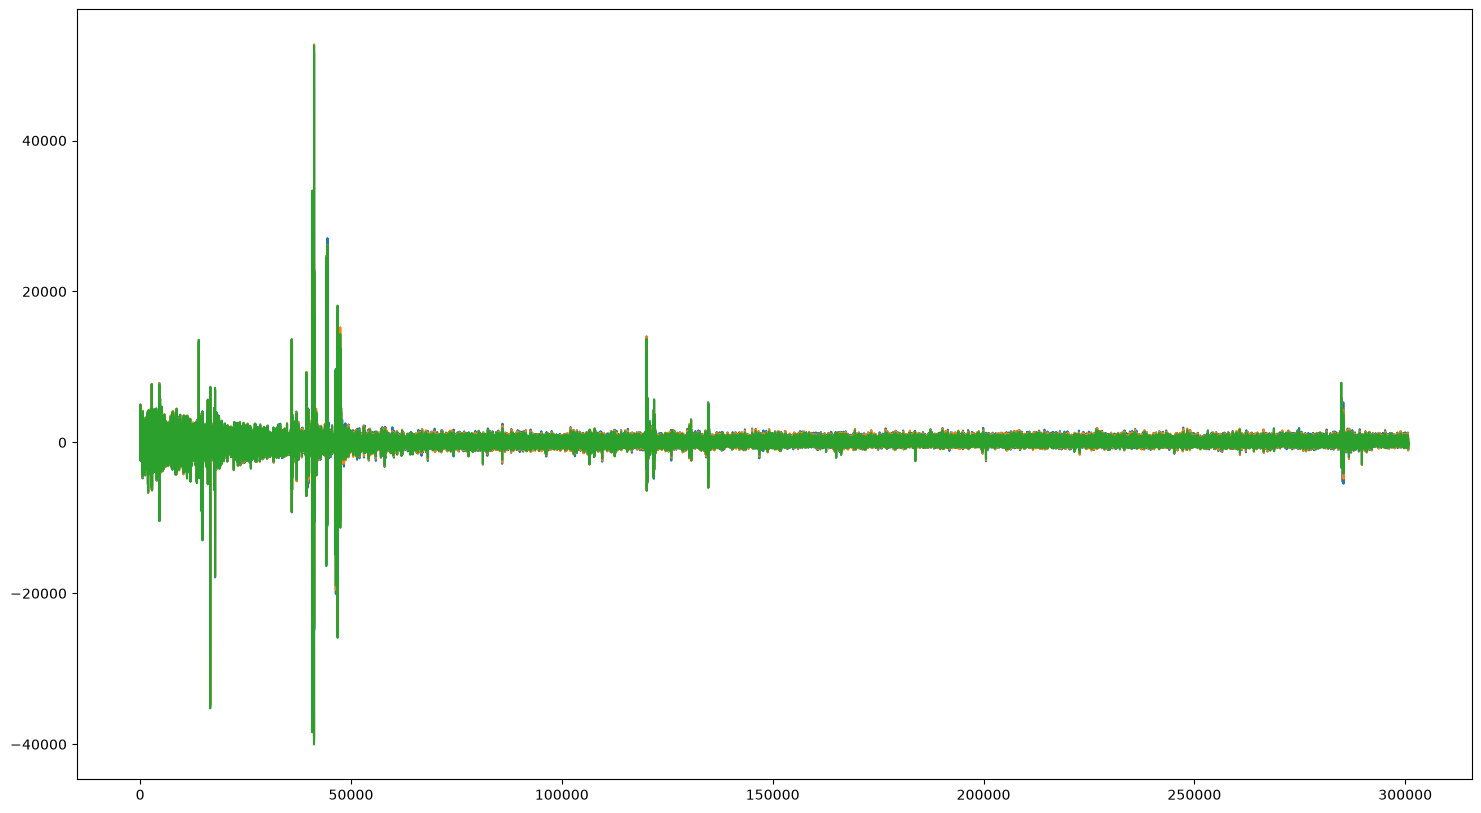

In [10]:
print(band_filtered.shape)
k=int(round(2*250))
print(k)
band_filtered_cutted = band_filtered[:, k:-k]
plt.figure(figsize=(18,10))
plt.plot(band_filtered_cutted[0])
plt.plot(band_filtered_cutted[1])
plt.plot(band_filtered_cutted[2])
print(band_filtered_cutted.shape)
plt.show()